# Import the Libraries

In [2]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

# Statistical tests
from scipy import stats

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

# Read the dataset

In [2]:
df = pd.read_csv('Islander_data.csv')
df.head(15)

,first_name,last_name,age,Happy_Sad_group,Dosage,Drug,Mem_Score_Before,Mem_Score_After,Diff
0,Bastian,Carrasco,25,H,1,A,63.5,61.2,-2.3
1,Evan,Carrasco,52,S,1,A,41.6,40.7,-0.9
2,Florencia,Carrasco,29,H,1,A,59.7,55.1,-4.6
3,Holly,Carrasco,50,S,1,A,51.7,51.2,-0.5
4,Justin,Carrasco,52,H,1,A,47.0,47.1,0.1
5,Liam,Carrasco,37,S,1,A,66.4,58.1,-8.3
6,Ava,Durand,35,S,1,A,44.1,56.0,11.9
7,Jamie,Durand,38,H,1,A,76.3,74.8,-1.5
8,Josefa,Durand,29,H,1,A,56.2,45.0,-11.2
9,Mark,Durand,36,S,1,A,54.8,75.9,21.1


In [3]:
df['Drug'].value_counts()

,count
Drug,
A,67
S,66
T,65


In [4]:
df['Happy_Sad_group'].value_counts()

,count
Happy_Sad_group,
H,99
S,99


In [5]:
df['Dosage'].value_counts()

,count
Dosage,
1,67
2,66
3,65


In [6]:
df['age'].unique()

array([25, 52, 29, 50, 37, 35, 38, 36, 63, 27, 39, 26, 48, 51, 44, 53, 55,
       31, 62, 40, 28, 68, 56, 54, 47, 43, 30, 32, 49, 34, 41, 45, 42, 72,
       33, 46, 59, 66, 65, 60, 83, 24, 69, 80, 73])

In [7]:
df['age'].min()

24

In [8]:
df['age'].max()

83

In [9]:
df['age'].mean()

np.float64(39.53030303030303)

In [4]:
df = pd.read_csv("Islander_data.csv")

df["Age_Category"] = pd.cut(
    df["age"],
    bins=[0, 35, 55, float("inf")],
    labels=["Young Adult", "Middle Age", "Older Adult"]
)

df.head()

,first_name,last_name,age,Happy_Sad_group,Dosage,Drug,Mem_Score_Before,Mem_Score_After,Diff,Age_Category
0,Bastian,Carrasco,25,H,1,A,63.5,61.2,-2.3,Young Adult
1,Evan,Carrasco,52,S,1,A,41.6,40.7,-0.9,Middle Age
2,Florencia,Carrasco,29,H,1,A,59.7,55.1,-4.6,Young Adult
3,Holly,Carrasco,50,S,1,A,51.7,51.2,-0.5,Middle Age
4,Justin,Carrasco,52,H,1,A,47.0,47.1,0.1,Middle Age


In [5]:
df.to_csv("Islander_data_with_age_categories.csv", index=False)


In [6]:
df['Age_Category'].value_counts()

,count
Age_Category,
Young Adult,93
Middle Age,87
Older Adult,18


In [12]:
df[df['Age_Category'] == 'Young Adult']

,first_name,last_name,age,Happy_Sad_group,Dosage,Drug,Mem_Score_Before,Mem_Score_After,Diff,Age_Category
0,Bastian,Carrasco,25,H,1,A,63.5,61.2,-2.3,Young Adult
2,Florencia,Carrasco,29,H,1,A,59.7,55.1,-4.6,Young Adult
6,Ava,Durand,35,S,1,A,44.1,56.0,11.9,Young Adult
8,Josefa,Durand,29,H,1,A,56.2,45.0,-11.2,Young Adult
11,Bastian,Gonzalez,27,S,1,A,52.3,63.7,11.4,Young Adult
...,...,...,...,...,...,...,...,...,...,...
187,Felipe,Kennedy,32,S,3,T,74.4,82.9,8.5,Young Adult
189,Daniel,Lopez,34,S,3,T,90.0,82.6,-7.4,Young Adult
190,Gregor,Lopez,34,H,3,T,68.8,77.4,8.6,Young Adult
191,Karin,Lopez,33,S,3,T,39.8,44.3,4.5,Young Adult


In [13]:
df[df['Age_Category'] == 'Young Adult']["age"].min()

24

In [14]:
df[df['Age_Category'] == 'Young Adult']["age"].max()

35

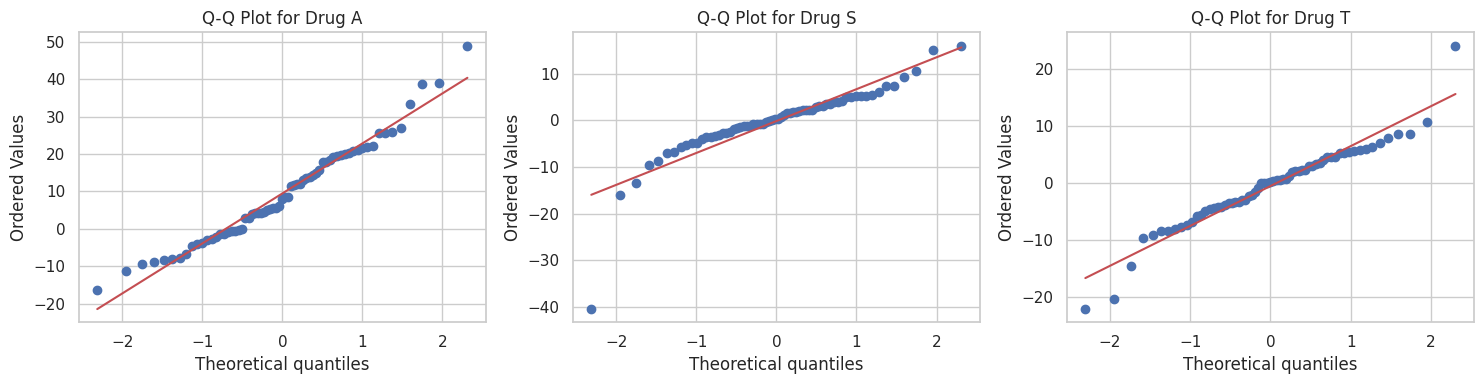

In [21]:
# ============================================================
# Q-Q Plots for One-Way ANOVA Normality Check
# Dataset: Islander_data_with_age_categories(1).csv
# Variable: Diff
# Group: Drug
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

# ------------------------------------------------------------
# 1. Load dataset
# ------------------------------------------------------------

df = pd.read_csv("Islander_data_with_age_categories.csv")

# ------------------------------------------------------------
# 2. Create Q-Q plots for Diff inside each Drug group
# ------------------------------------------------------------

drug_groups = df["Drug"].unique()

plt.figure(figsize=(15, 4))

for i, drug in enumerate(drug_groups, 1):

    # Select Diff values for one drug group
    group_data = df[df["Drug"] == drug]["Diff"].dropna()

    # Create subplot
    plt.subplot(1, len(drug_groups), i)

    # Q-Q plot
    stats.probplot(group_data, dist="norm", plot=plt)

    plt.title(f"Q-Q Plot for Drug {drug}")

plt.tight_layout()
plt.show()

# ANOVA One Way Test

  first_name last_name  age Happy_Sad_group  Dosage Drug  Mem_Score_Before  Mem_Score_After  Diff Age_Category
0    Bastian  Carrasco   25               H       1    A              63.5             61.2  -2.3  Young Adult
1       Evan  Carrasco   52               S       1    A              41.6             40.7  -0.9   Middle Age
2  Florencia  Carrasco   29               H       1    A              59.7             55.1  -4.6  Young Adult
3      Holly  Carrasco   50               S       1    A              51.7             51.2  -0.5   Middle Age
4     Justin  Carrasco   52               H       1    A              47.0             47.1   0.1   Middle Age

Drug groups:
Drug
A    67
S    66
T    65
Name: count, dtype: int64

Summary statistics for memory score difference by Drug:
      count      mean        std   min   max
Drug                                        
A        67  9.470149  13.253930 -16.3  49.0
S        66 -0.171212   7.499923 -40.4  16.0
T        65 -0.587692   7.10

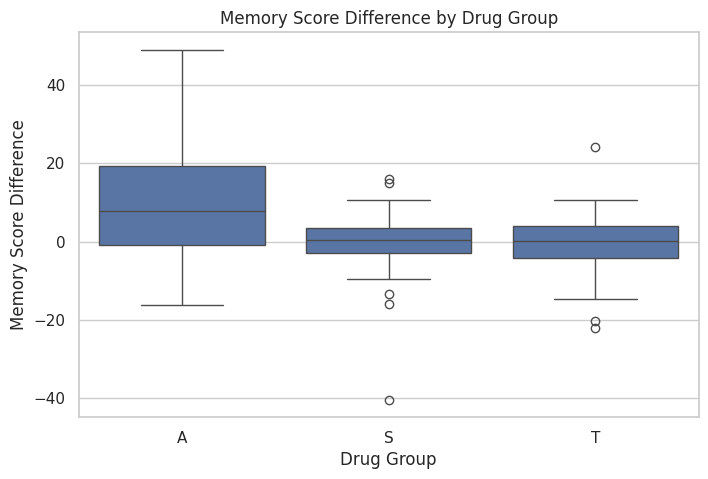


One-Way ANOVA Result
--------------------
F-statistic: 22.711288522955336
P-value: 1.359214288302846e-09

Decision: Reject the null hypothesis.
Conclusion: There is a statistically significant difference
in mean memory score difference between at least two drug groups.


In [20]:
# ============================================================
# One-Way ANOVA Test
# Dataset: Islander_data_with_age_categories(1).csv
# Question:
# Is there a significant difference in memory score change
# between Drug A, Drug S, and Drug T?
# ============================================================

import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. Load the dataset
# ------------------------------------------------------------

df = pd.read_csv("Islander_data_with_age_categories.csv")

# Show first few rows
print(df.head())

# ------------------------------------------------------------
# 2. Check the groups in the Drug column
# ------------------------------------------------------------

print("\nDrug groups:")
print(df["Drug"].value_counts())

# ------------------------------------------------------------
# 3. Show summary statistics for each drug group
# ------------------------------------------------------------

summary = df.groupby("Drug")["Diff"].agg(["count", "mean", "std", "min", "max"])

print("\nSummary statistics for memory score difference by Drug:")
print(summary)

# ------------------------------------------------------------
# 4. Visualization: Boxplot
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Drug",
    y="Diff"
)

plt.title("Memory Score Difference by Drug Group")
plt.xlabel("Drug Group")
plt.ylabel("Memory Score Difference")
plt.show()

# ------------------------------------------------------------
# 5. Separate the Diff values for each drug group
# ------------------------------------------------------------

drug_A = df[df["Drug"] == "A"]["Diff"]
drug_S = df[df["Drug"] == "S"]["Diff"]
drug_T = df[df["Drug"] == "T"]["Diff"]

# ------------------------------------------------------------
# 6. Perform One-Way ANOVA
# ------------------------------------------------------------

f_statistic, p_value = stats.f_oneway(drug_A, drug_S, drug_T)

print("\nOne-Way ANOVA Result")
print("--------------------")
print("F-statistic:", f_statistic)
print("P-value:", p_value)

# ------------------------------------------------------------
# 7. Decision
# ------------------------------------------------------------

alpha = 0.05

if p_value < alpha:
    print("\nDecision: Reject the null hypothesis.")
    print("Conclusion: There is a statistically significant difference")
    print("in mean memory score difference between at least two drug groups.")
else:
    print("\nDecision: Fail to reject the null hypothesis.")
    print("Conclusion: There is no statistically significant difference")
    print("in mean memory score difference between the drug groups.")

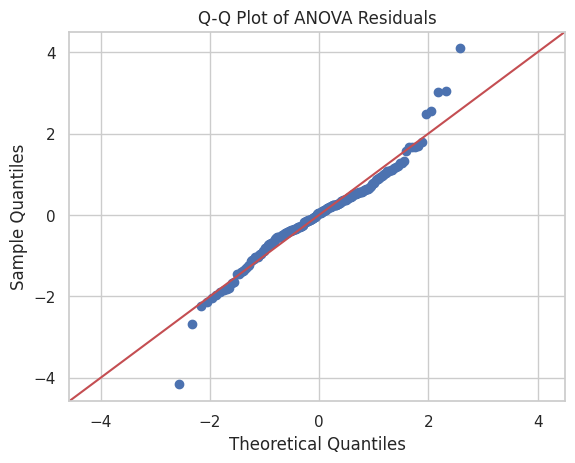

In [22]:
# ============================================================
# Q-Q Plot of ANOVA Residuals
# ============================================================

import statsmodels.formula.api as smf
import statsmodels.api as sm

# ------------------------------------------------------------
# 1. Build one-way ANOVA model
# ------------------------------------------------------------

model = smf.ols("Diff ~ C(Drug)", data=df).fit()

# ------------------------------------------------------------
# 2. Get residuals
# Residual = actual value - predicted group mean
# ------------------------------------------------------------

residuals = model.resid

# ------------------------------------------------------------
# 3. Q-Q plot of residuals
# ------------------------------------------------------------

sm.qqplot(residuals, line="45", fit=True)

plt.title("Q-Q Plot of ANOVA Residuals")
plt.show()

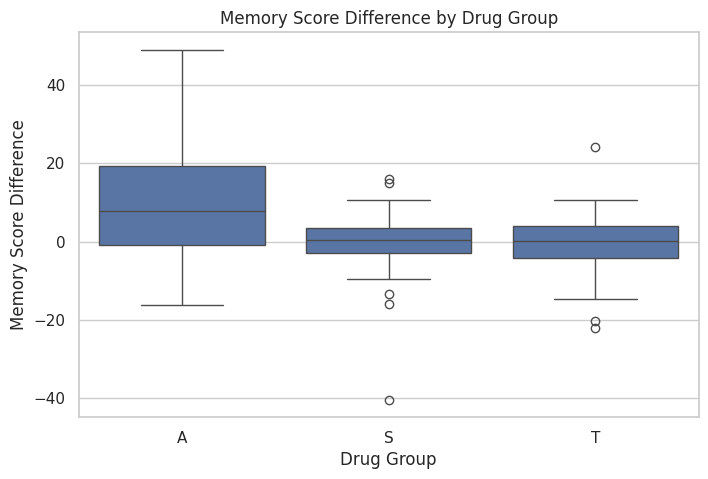

In [23]:
# ============================================================
# Boxplot: Diff by Drug Group
# ============================================================

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Drug",
    y="Diff"
)

plt.title("Memory Score Difference by Drug Group")
plt.xlabel("Drug Group")
plt.ylabel("Memory Score Difference")
plt.show()

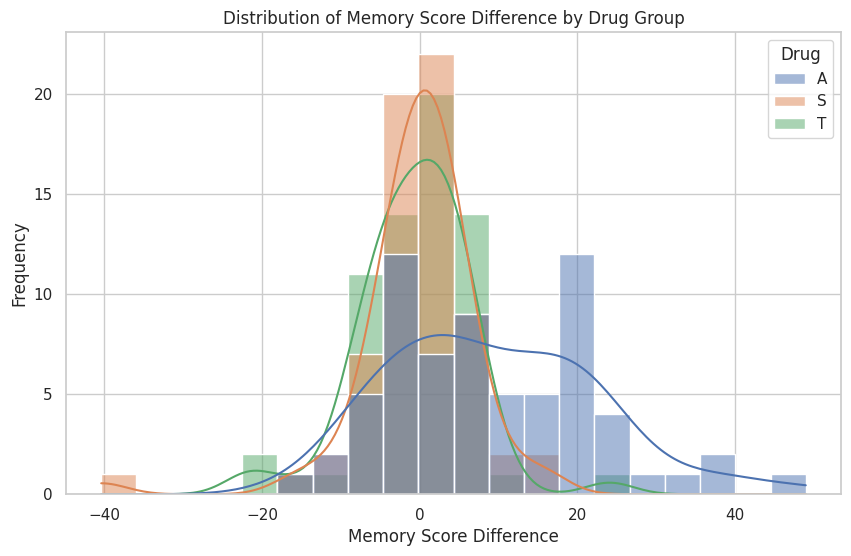

In [24]:
# ============================================================
# Histogram/KDE: Diff Distribution by Drug Group
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Diff",
    hue="Drug",
    kde=True,
    bins=20,
    alpha=0.5
)

plt.title("Distribution of Memory Score Difference by Drug Group")
plt.xlabel("Memory Score Difference")
plt.ylabel("Frequency")
plt.show()

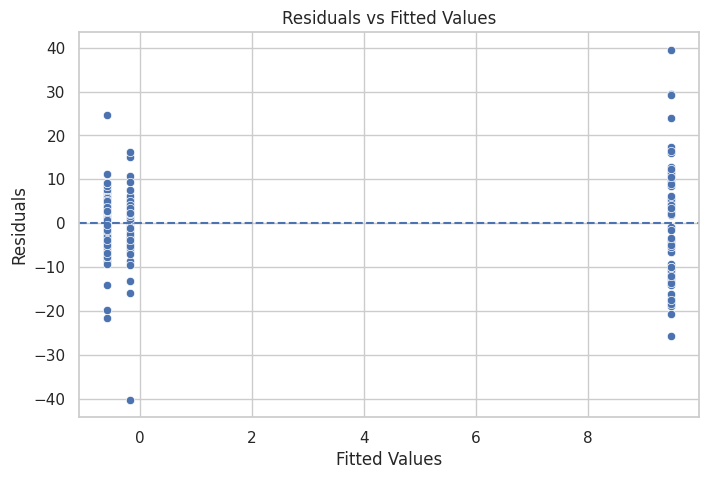

In [25]:
# ============================================================
# Residuals vs Fitted Plot
# ============================================================

fitted_values = model.fittedvalues
residuals = model.resid

plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=fitted_values,
    y=residuals
)

plt.axhline(0, linestyle="--")

plt.title("Residuals vs Fitted Values")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.show()